#### FPVS pypeline 2 pynt 0
This is the second edition of the FPVS pypeline where all processes/steps in the pipeline are functionalized so that they can be completed in a more streamlined manner in addition to this application being distributed as a package. 
steps 

1. Preprocess step 1

## Import libraries

In [12]:
%reset -f
import cust_funcs as cf
import FPVS_pycage as FPVS
from pathlib import Path
import importlib
import scipy.io as sci
# importlib.reload(FPVS)

## Preprocessing phase 1 
0. Remodelling the lw6 and mat data to make them more Python-friendly
1. Rename channels
2. Changing the channel locations and adding spherical coordinates to the meta (lw6) data
3. Downsampling the mat_data 
4. Deleting the EXG X and status channels
5. Bandpass and notch filtering

In [13]:
importlib.reload(cf)
importlib.reload(FPVS)
matfilepath = Path("D:\Goffaux lab\Data set\Python files\BEFR2711.mat")
lw6filepath = matfilepath.with_suffix(".lw6")
subjid = matfilepath.stem
mat_data, meta_data , metafilepath = FPVS.preprocessFPVSdata_phase1(matfilepath,lw6filepath)

the keys in old data are:  ('filetype', 'name', 'tags', 'history', 'datasize', 'xstart', 'ystart', 'zstart', 'xstep', 'ystep', 'zstep', 'chanlocs', 'events')
the keys in the new data are:  dict_keys(['filetype', 'name', 'tags', 'history', 'origins', 'datasize', 'xstart', 'ystart', 'zstart', 'xstep', 'ystep', 'zstep', 'chanlocs', 'events', 'fs', 'activation', 'fields'])
D:\Goffaux lab\Data set\Python files\BEFR2711.pkl
data is saved as:  D:\Goffaux lab\Data set\Python files\BEFR2711.pkl


channels are renamed and saved in and as:  D:\Goffaux lab\Data set\Python files\1_chanlabels BEFR2711.pkl


elec. locations are changed! and saved as  D:\Goffaux lab\Data set\Python files\2_chanlocs 1_chanlabels BEFR2711


Data is downsampled! by a factor of  8  and saved as  D:\Goffaux lab\Data set\Python files\3_ds 2_chanlocs 1_chanlabels BEFR2711


channels being deleted are:  ['EXG5', 'EXG6', 'EXG7', 'EXG8', 'Status']

 data saved in  D:\Goffaux lab\Data set\Python files\4_chan-select 3_ds 2_chanlo

In [ ]:
meta_data["chanlocs"]["labels"]
meta_data["chanlocs"][0][0]["labels"]


## Performing ICA 
Because jupyter is asynchronous, i have to split the perform_ICA, overlay ICA and apply ICA separately, in three different cells. 

In [ ]:
print(metafilepath)

In [ ]:
importlib.reload(FPVS)
matfilepath = metafilepath.with_suffix('.npy')
metafilepath = metafilepath.with_suffix('.pkl')

print(metafilepath.exists())
print(metafilepath)
print(matfilepath)
ica, raw, ica_data, idx = FPVS.preprocessFPVSdata_performICA(matfilepath=matfilepath, metafilepath = metafilepath)

## Overlay ICA data on actual activation

In [ ]:
importlib.reload(FPVS)
FPVS.overlayICAondata(matfilepath,metafilepath,ica_data)

## Apply ICA to the actual data. 

In [ ]:
## rmidx is the variable where the Independent components with blink are stored and will be removed in the next cell
# rmidx = [0,2,3,7,8,9,10,12] #ADVI
rmidx = [0,2,3,5,6,9,11,13,15,16,17,18,19,20,21,23,24] # 24 looks dicey CHMA


In [ ]:
importlib.reload(cf)
importlib.reload(FPVS)
mat_data, meta_data, metafilepath = FPVS.preprocessFPVSdata_applyICA(matfilepath, metafilepath, ica , raw, rmidx)

## Interpolate channels

In [ ]:
matfilepath = metafilepath.with_suffix('.npy')
metafilepath = metafilepath.with_suffix('.pkl')
print(matfilepath)
mat_data = np.load(matfilepath)
meta_data = cf.loadMetadata(metafilepath)
cf.showmeSignalUI(mat_data, meta_data,ylim=150)

In [ ]:
interp_chnames = ['P1','P3','PO3']
bad_chids = ['Fp1','CP6','I2']
print(labels)

In [ ]:
importlib.reload(FPVS)
mat_data,meta_data,metafile = FPVS.preprocessFPVSdata_phase2(matfilepath,metafilepath,interp_chnames=interp_chnames,bad_but_ignore=bad_chids)

## Segmenting the data 

In [14]:
importlib.reload(cf)
importlib.reload(FPVS)
print(metafilepath)
metafilepath = metafilepath.with_suffix('.pkl')
matfilepath = metafilepath.with_suffix('.npy')
mat_data, meta_data, metafilepath = FPVS.preprocesssFPVSdata_segmentation(matfilepath, metafilepath)

D:\Goffaux lab\Data set\Python files\6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels BEFR2711.npy
Event label being split:  10  number of reps:  5
Event label being split:  135  number of reps:  5
Event label being split:  200  number of reps:  5
Event label being split:  210  number of reps:  2
Event label being split:  212  number of reps:  2
Event label being split:  214  number of reps:  2
Event label being split:  216  number of reps:  2
Event label being split:  218  number of reps:  2
Event label being split:  220  number of reps:  2
Event label being split:  222  number of reps:  2
Event label being split:  224  number of reps:  2
Event label being split:  45  number of reps:  5
Event label being split:  90  number of reps:  5
[[ 172986.  190906.]
 [ 229526.  247446.]
 [ 332927.  350847.]
 [ 418097.  436017.]
 [ 474321.  492241.]
 [  94983.  112903.]
 [ 255897.  273817.]
 [ 363823.  381743.]
 [ 501246.  519166.]
 [ 558091.  576011.]
 [   4690.   22610.]
 [ 14

## Sanity checks

In [ ]:
import numpy as np
importlib.reload(cf)
matfilepath = metafilepath.with_suffix('.npy')
metafilepath = metafilepath.with_suffix('.pkl')
mat_data = np.load(matfilepath)
meta_data = cf.loadMetadata(metafilepath)

fs = meta_data['fs']
chid = 26
subjid = matfilepath.stem.split()[-1]
epochid = 27
signal = mat_data[:,chid,epochid]
label = meta_data["chanlocs"]["labels"][chid]
cf.showmeSummaryPlot(signal = signal, fs = fs, chname = label, subjid = subjid,epochid = epochid,freqlim = [0, 12])

In [16]:
print(meta_data['chanlocs']['labels'])
print(mat_data.shape)

['Fp1' 'AF7' 'AF3' 'F1' 'F3' 'F5' 'F7' 'FT7' 'FC5' 'FC3' 'FC1' 'C1' 'C3'
 'C5' 'T7' 'TP7' 'CP5' 'CP3' 'CP1' 'P1' 'P3' 'P5' 'P7' 'P9' 'PO7' 'PO3'
 'O1' 'Iz' 'Oz' 'POz' 'Pz' 'CPz' 'Fpz' 'Fp2' 'AF8' 'AF4' 'AFz' 'Fz' 'F2'
 'F4' 'F6' 'F8' 'FT8' 'FC6' 'FC4' 'FC2' 'FCz' 'Cz' 'C2' 'C4' 'C6' 'T8'
 'TP8' 'CP6' 'CP4' 'CP2' 'P2' 'P4' 'P6' 'P8' 'P10' 'PO8' 'PO4' 'O2' 'I1'
 'I2' 'PO9' 'PO10']
(17920, 68, 41)


In [24]:
import numpy as np
for key in meta_data["chanlocs"].keys():
    print(key," has the shape: ", np.shape(meta_data["chanlocs"][key]))

print(odd_data.shape)

labels  has the shape:  (68,)
topo_enabled  has the shape:  (68,)
SEEG_enabled  has the shape:  (68,)
radius  has the shape:  (68,)
sph_phi  has the shape:  (68,)
sph_theta  has the shape:  (68,)
sph_phi_besa  has the shape:  (68,)
sph_theta_besa  has the shape:  (68,)
X  has the shape:  (68,)
Y  has the shape:  (68,)
Z  has the shape:  (68,)
(29, 70)


## Post processing 
1. FFT transform
2. averaging within trials
3. Frequency window chunking
4. Chunk selection( and splitting based on baseline and oddball chunks)
5. Sum of chunks/harmonics
6. baseline correction (I havent done SNR correction yet)

In [19]:
importlib.reload(FPVS)
folderPath = Path("D:\Goffaux lab\Data set\Python files\8_ref8_ref3_interp 7_ep 6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels BEFR2711.npy")
odd_data, bl_data, oddfilepath, blfilepath = FPVS.postprocessFPVSdata("200", folderPath.parent)

The event you're running this script for is 200


200 ADVI0407
(17920, 70, 5)
200 BEFR2711
(17920, 70, 5)
200 CHMA0501
(17920, 70, 5)
200 DAAN0411
(17920, 70, 5)
200 DAFE1803
(17920, 70, 5)
200 MERGED
(17920, 70, 25)
data is merged based on epochs, saved as:  D:\Goffaux lab\Data set\Python files\200 MERGED.npy


FFT data is saved as  D:\Goffaux lab\Data set\Python files\10_FFT 200 MERGED


averaged data is saved as  D:\Goffaux lab\Data set\Python files\11_avg 10_FFT 200 MERGED


data is chunked at frequencies of interest and saved as  D:\Goffaux lab\Data set\Python files\12_chunk 11_avg 10_FFT 200 MERGED


baseline data saved, size of the data in  D:\Goffaux lab\Data set\Python files\13_baseline 12_chunk 11_avg 10_FFT 200 MERGED


oddball data saved, size of the data in  D:\Goffaux lab\Data set\Python files\13_oddball 12_chunk 11_avg 10_FFT 200 MERGED


Harmonics of bl_data is summed and the new shape is: (29, 70)


Harmonics of odd_data is summed and the new shape is: (29, 70)




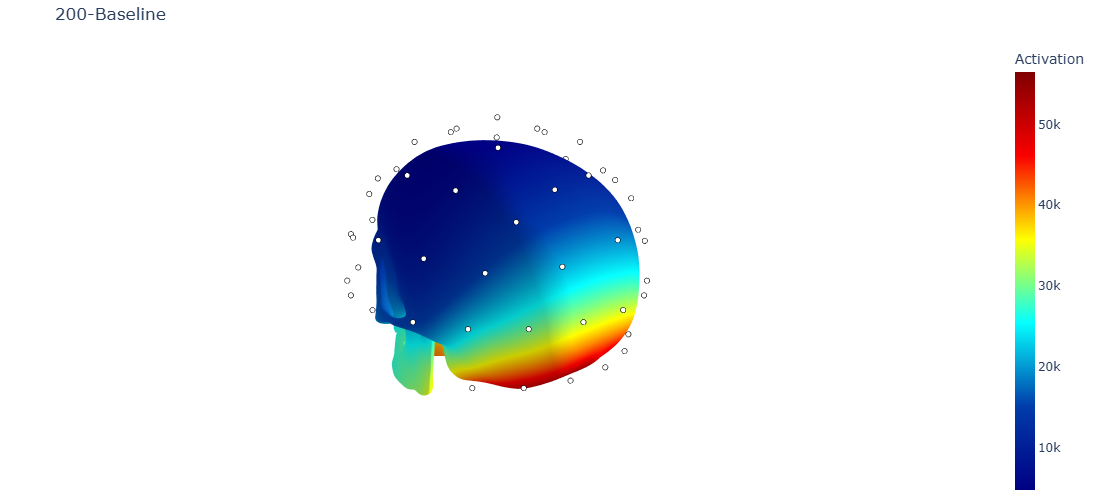

In [38]:
# del mat_data
# del meta_data
del odd_data
del mat_data
event_label = "200"
metafilepath = Path("D:\Goffaux lab\Data set\Python files\split 8_ref 7_ep 6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels CHMA0501.pkl")
matfilepath = Path("D:\Goffaux lab\Data set\Python files\\14_sum 13_oddball 12_chunk 11_avg 10_FFT 200 MERGED.npy")
odd_data = np.load(matfilepath)
meta_data = cf.loadMetadata(metafilepath)
# print(bl_data.shape)
titlestr = f"{event_label}-Baseline"
%matplotlib widget
freqid = bl_data.shape[0]//2-1
# cf.showmeTopomap(bl_data[bl_data.shape[0]//2,:],meta_data)
cf.showme3DTopomap(odd_data[freqid,:],meta_data,titlestr)


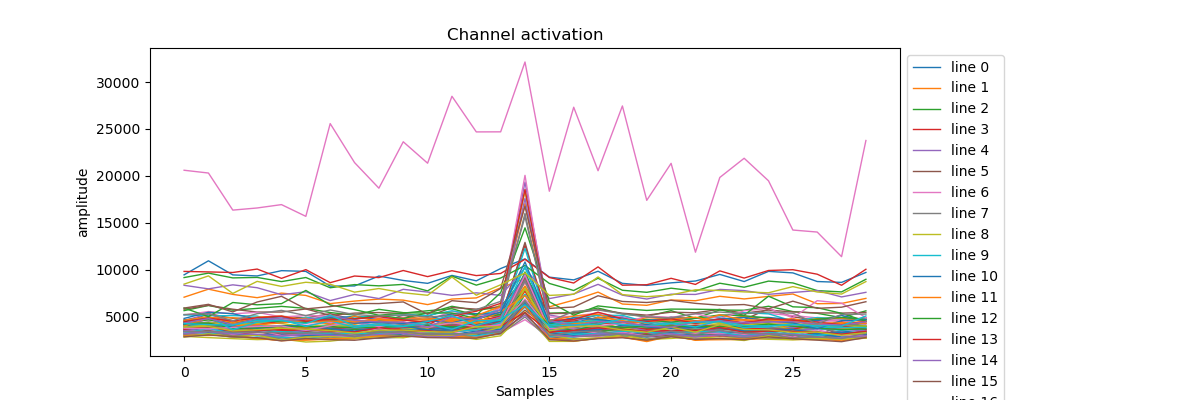

In [34]:
cf.showmeSignal(bl_data)

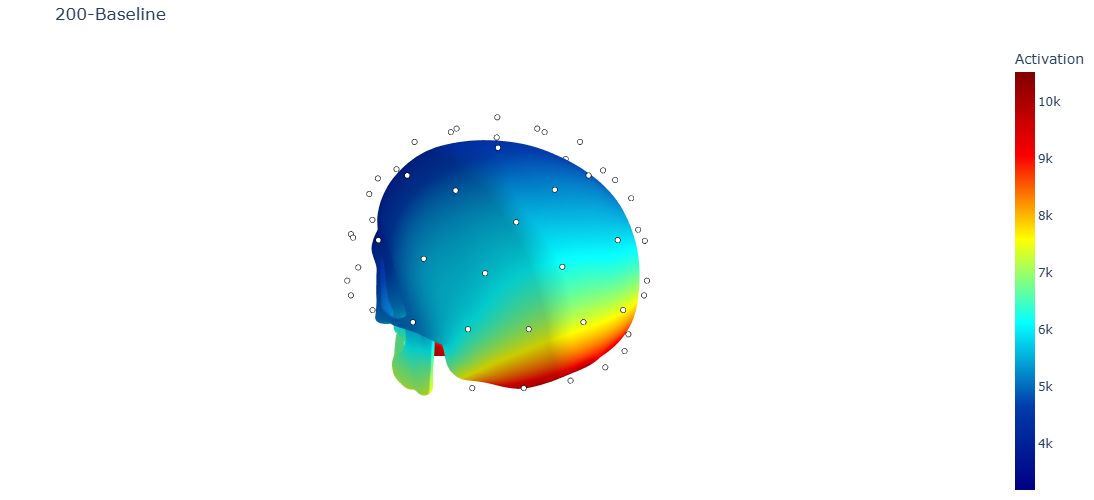

In [36]:

event_label = "200"
metafilepath = Path("D:\Goffaux lab\Data set\Python files\split 8_ref 7_ep 6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels CHMA0501.pkl")
matfilepath = Path("D:\Goffaux lab\Data set\Python files\\14_sum 13_baseline 12_chunk 11_avg 10_FFT 200 MERGED.npy")
bl_data = np.load(matfilepath)
meta_data = cf.loadMetadata(metafilepath)
# print(bl_data.shape)
titlestr = f"{event_label}-Baseline"
%matplotlib widget
freqid = bl_data.shape[0]//2-1
# cf.showmeTopomap(bl_data[bl_data.shape[0]//2,:],meta_data)
cf.showme3DTopomap(bl_data[freqid,:],meta_data,titlestr)